**Public Transport Demand Forecasting**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("/content/Public_Transport_Demand_Forecasting.xlsx")

In [ ]:
df.head()

,Record_ID,Date,City,Route_Type,Route_ID,Day_Type,Season,Weather_Condition,Temperature_C,Rainfall_mm,...,Connectivity_Index,Avg_Speed_kmph,On_Time_Rate_pct,Breakdown_Rate_pct,Special_Event,Internet_Availability_Flag,CCTV_Coverage_Flag,GDP_per_Capita_INR,Unemployment_Rate_pct,Passenger_Demand
0,1,2022-01-01,Pune,Bus,RT-297,Weekday,Winter,Cloudy,33.8,1.9,...,0.83,36.2,75.6,3.17,NaN,1,1,162762,4.7,1051
1,2,2022-01-02,Bangalore,Bus,RT-745,Weekend,Summer,Rainy,36.4,0.0,...,0.84,40.1,56.9,6.74,NaN,0,1,240094,2.6,955
2,3,2022-01-03,Hyderabad,Auto-Rickshaw,RT-678,Weekday,Winter,Rainy,38.3,1.3,...,0.55,36.6,68.3,6.88,Strike,0,1,280401,8.7,557
3,4,2022-01-04,Pune,Bus,RT-490,Weekday,Monsoon,Clear,32.7,0.0,...,0.49,35.8,67.6,3.68,NaN,1,1,137941,4.4,1608
4,5,2022-01-05,Delhi,Metro,RT-278,Weekend,Spring,Cloudy,20.1,0.0,...,0.86,28.0,89.9,1.00,NaN,0,1,266670,11.0,936


In [26]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Record_ID                   500 non-null    int64         
 1   Date                        500 non-null    datetime64[ns]
 2   City                        500 non-null    object        
 3   Route_Type                  500 non-null    object        
 4   Route_ID                    500 non-null    object        
 5   Day_Type                    500 non-null    object        
 6   Season                      500 non-null    object        
 7   Weather_Condition           500 non-null    object        
 8   Temperature_C               500 non-null    float64       
 9   Rainfall_mm                 500 non-null    float64       
 10  Hour_of_Day                 500 non-null    int64         
 11  Peak_Hour_Flag              500 non-null    int64         

In [27]:
df.shape

(500, 30)

In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Record_ID                   500 non-null    int64         
 1   Date                        500 non-null    datetime64[ns]
 2   City                        500 non-null    object        
 3   Route_Type                  500 non-null    object        
 4   Route_ID                    500 non-null    object        
 5   Day_Type                    500 non-null    object        
 6   Season                      500 non-null    object        
 7   Weather_Condition           500 non-null    object        
 8   Temperature_C               500 non-null    float64       
 9   Rainfall_mm                 500 non-null    float64       
 10  Hour_of_Day                 500 non-null    int64         
 11  Peak_Hour_Flag              500 non-null    int64         

In [29]:
df.duplicated().value_counts()

,count
False,500


In [30]:
print(df.isnull().sum())

Record_ID                       0
Date                            0
City                            0
Route_Type                      0
Route_ID                        0
Day_Type                        0
Season                          0
Weather_Condition               0
Temperature_C                   0
Rainfall_mm                     0
Hour_of_Day                     0
Peak_Hour_Flag                  0
Fare_INR                        0
Route_Length_km                 0
Num_Stops                       0
Fleet_Size                      0
Operational_Hours               0
Population_Density_per_km2      0
Nearby_Employment_Zones         0
Nearby_Schools_Colleges         0
Connectivity_Index              0
Avg_Speed_kmph                  0
On_Time_Rate_pct                0
Breakdown_Rate_pct              0
Special_Event                 349
Internet_Availability_Flag      0
CCTV_Coverage_Flag              0
GDP_per_Capita_INR              0
Unemployment_Rate_pct           0
Passenger_Dema

In [ ]:
missing = df.isnull().sum()

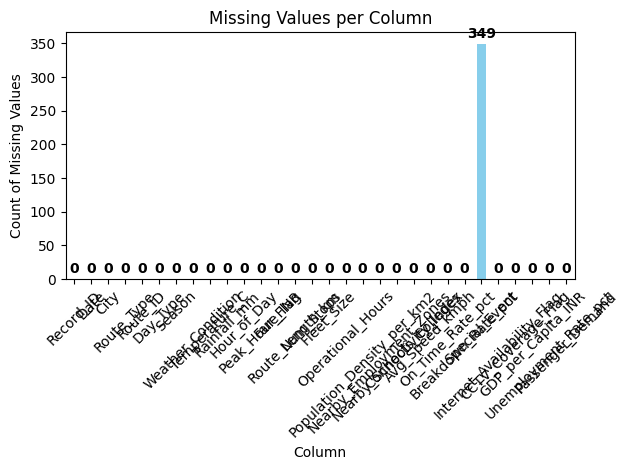

In [ ]:
ax = missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)

for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

1.Passenger demand forecating(Histogram)

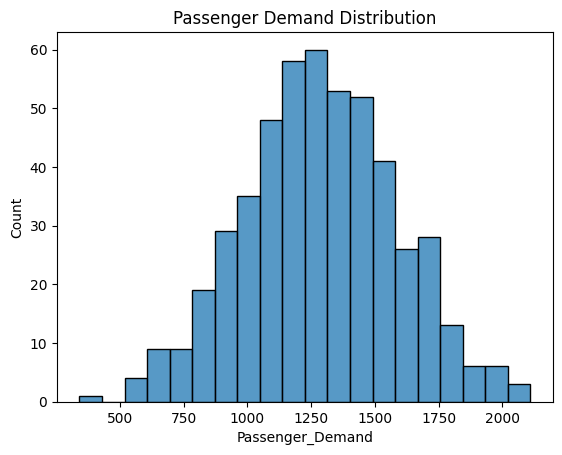

In [ ]:
sns.histplot(df['Passenger_Demand'], bins=20)
plt.title("Passenger Demand Distribution")
plt.show()

2.Daily demand trend(TimeSeries Line plot)

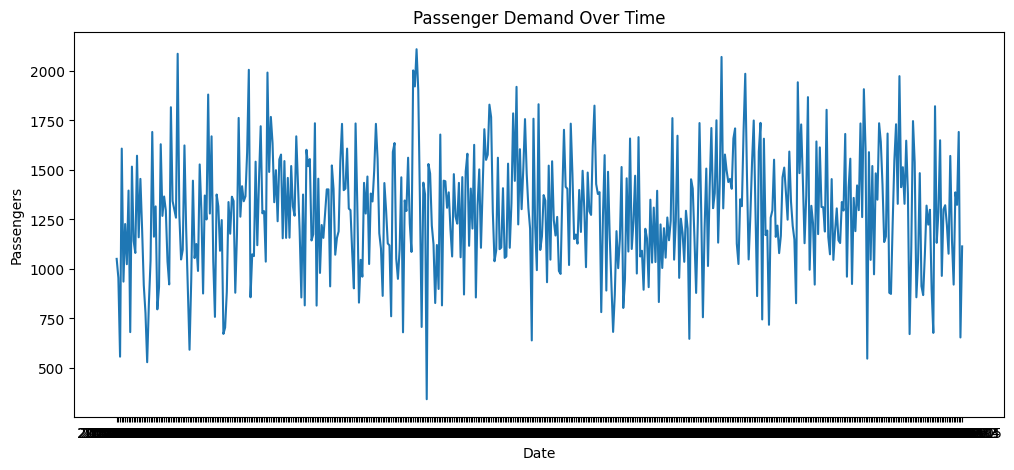

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Passenger_Demand'])
plt.title("Passenger Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.show()

3.Special Event Demand(Barplot)

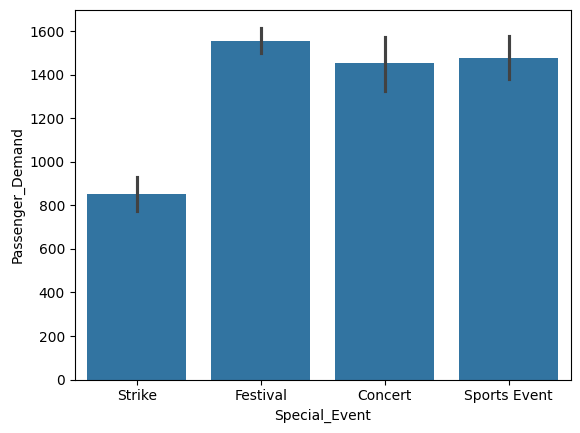

In [ ]:
sns.barplot(x='Special_Event', y='Passenger_Demand', data=df)
plt.show()

4.Outlier Detection(Boxplot & Stripplot)

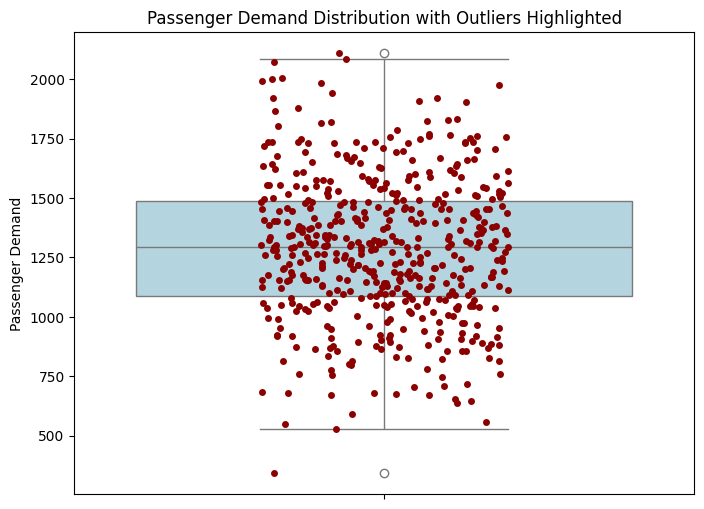

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Passenger_Demand'], color='lightblue')
sns.stripplot(y=df['Passenger_Demand'], color='darkred', jitter=0.2, size=5)
plt.title('Passenger Demand Distribution with Outliers Highlighted')
plt.ylabel('Passenger Demand')
plt.show()

5.Weekday Analysis(Pie chart)


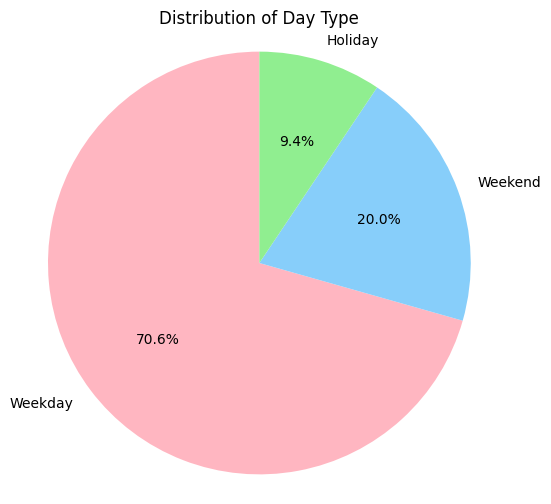

In [ ]:
day_type_counts = df['Day_Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(day_type_counts, labels=day_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightpink', 'lightskyblue','lightgreen'])
plt.title('Distribution of Day Type')
plt.axis('equal')
plt.show()

6.Correlation Heatmap

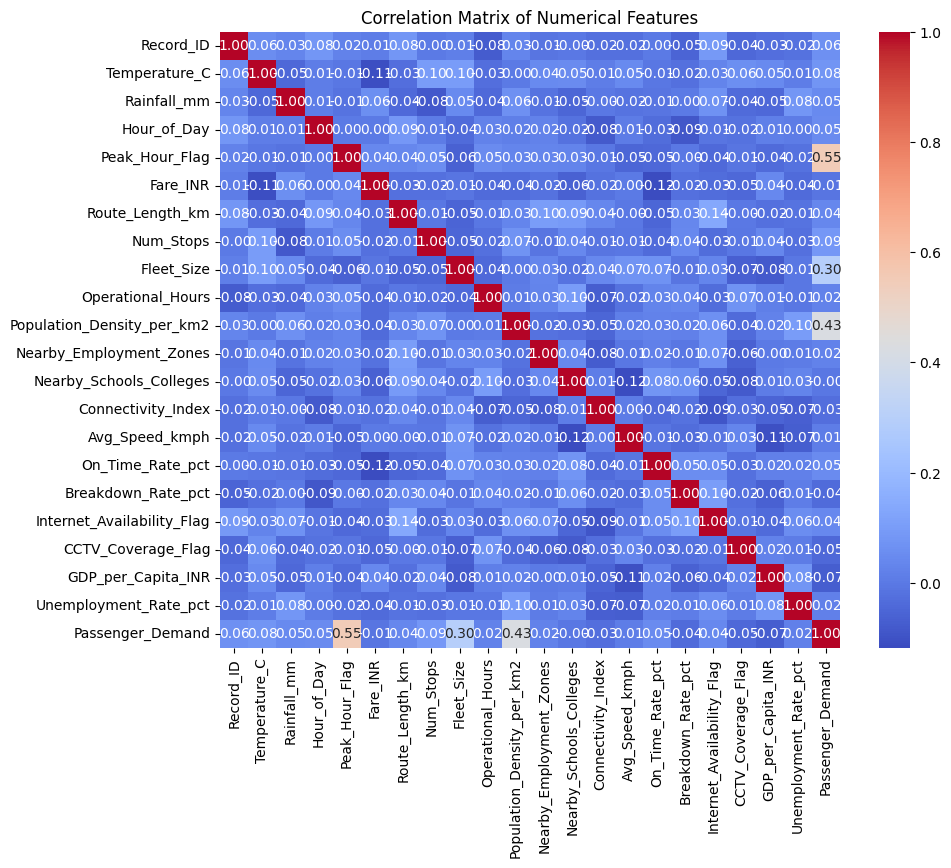

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## EDA Conclusion

Based on the Exploratory Data Analysis, here's a summary of the key findings:

*   **Data Overview:** The dataset contains 500 records and 30 features, with no duplicate entries detected.
*   **Missing Values:** The `Special_Event` column has a significant number of missing values (349 out of 500), which will require attention (e.g., imputation or strategic handling) if this feature is to be used in modeling.
*   **Data Types:** The `Date` column has been successfully converted to a `datetime` format, which is crucial for time-series analysis and date-based operations.
*   **Passenger Demand Distribution:** The histogram shows the distribution of `Passenger_Demand`, giving an idea of its typical range and variability. The time-series plot of `Passenger_Demand` over time reveals daily fluctuations, suggesting potential underlying patterns related to time, day type, or external events.
*   **Day Type Analysis:** The pie chart illustrates the distribution of `Day_Type` (Weekday, Weekend, Holiday), showing the proportion of each in the dataset, which is crucial for understanding demand variations across different types of days.
*   **Feature Relationships:** The correlation heatmap provides an initial look at the linear relationships between numerical features. This can help in identifying potential predictors for `Passenger_Demand` and understanding multicollinearity among independent variables. For example, `Temperature_C` and `Rainfall_mm` might have some correlation with `Passenger_Demand`.